In [ ]:
print("Car Damage Detection")

Car Damage Detection


In [ ]:
# Import necessary libraries
import os
import zipfile
import requests

# URL to your dataset zip file in the GitHub repository
dataset_url = 'https://raw.githubusercontent.com/rafdimilzano/data/main/cdadataset.zip'  # Change this URL to your dataset location

# Download the dataset
dataset_zip_path = 'cdadataset.zip'
response = requests.get(dataset_url)

# Save the zip file locally
with open(dataset_zip_path, 'wb') as file:
    file.write(response.content)

# Unzip the dataset
with zipfile.ZipFile(dataset_zip_path, 'r') as zip_ref:
    zip_ref.extractall('dataset')  # Extract the dataset into the 'dataset' folder

# Check the unzipped folder structure
os.listdir('dataset')


['validation', 'training']

In [ ]:
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from tensorflow import keras
import matplotlib.pyplot as plt

In [ ]:
# Set dataset paths
train_dir = 'dataset/training'    # Path to the Training set
val_dir = 'dataset/validation'    # Path to the Validation set
image_size = (224, 224)  # Resize images to 224x224
batch_size = 32

# Image augmentation for the training set to improve generalization
train_datagen = ImageDataGenerator(
    rescale=1.0/255,            # Rescale pixel values to [0, 1]
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

# No augmentation for validation data, only rescaling
val_datagen = ImageDataGenerator(rescale=1.0/255)

# Loading training data from the structured directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

# Loading validation data from the structured directories
validation_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical'
)


Found 1383 images belonging to 3 classes.
Found 248 images belonging to 3 classes.


In [ ]:
print(train_generator)

In [ ]:
num_classes = 3  # Since we have three classes: minor, moderate, and severe

# Build the CNN model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),

    Conv2D(256, (3, 3), activation='relu'),
    MaxPool2D(pool_size=(2, 2)),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')  # 3 output classes
])


# Compile the model
model.compile(optimizer=keras.optimizers.Adam(1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# Set up early stopping and model checkpoint callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
checkpoint = ModelCheckpoint('car_damage_model.keras', save_best_only=True, monitor='val_accuracy')

# Train the model
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=20,
    callbacks=[early_stopping, checkpoint]
)


Epoch 1/20


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


44/44 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.3348 - loss: 1.1073 - val_accuracy: 0.4879 - val_loss: 1.0682
Epoch 2/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 204s 4s/step - accuracy: 0.4099 - loss: 1.0653 - val_accuracy: 0.5444 - val_loss: 0.9600
Epoch 3/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 201s 4s/step - accuracy: 0.4942 - loss: 1.0112 - val_accuracy: 0.5605 - val_loss: 0.9300
Epoch 4/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.5353 - loss: 0.9601 - val_accuracy: 0.5484 - val_loss: 0.9409
Epoch 5/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 203s 4s/step - accuracy: 0.5146 - loss: 0.9747 - val_accuracy: 0.5605 - val_loss: 0.9027
Epoch 6/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - accuracy: 0.5261 - loss: 0.9519 - val_accuracy: 0.5847 - val_loss: 0.8910
Epoch 7/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - accuracy: 0.5359 - loss: 0.9274 - val_accuracy: 0.5968 - val_loss: 0.8820
Epoch 8/20
44/44 ━━━━━━━━━━━━━━━━━━━━ 194s 4s/step - accuracy: 0.5400 - loss: 0.9446 - val_accuracy: 0.5161 - val_loss: 0.

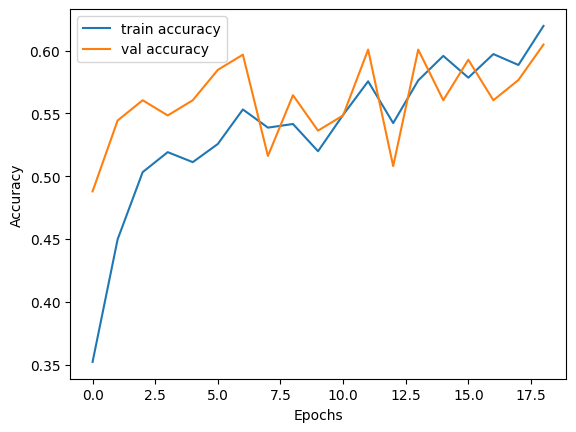

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.6217 - loss: 0.8154
Validation Accuracy: 60.08%


In [ ]:
# Plot the training history for accuracy
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate the model on validation data
val_loss, val_acc = model.evaluate(validation_generator)
print(f"Validation Accuracy: {val_acc*100:.2f}%")


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# Generate predictions and true labels for the classification report
y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = validation_generator.classes
class_labels = list(validation_generator.class_indices.keys())

# Print the classification report
print("Classification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_labels, digits=3))

8/8 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step
Classification Report:
              precision    recall  f1-score   support

    01-minor      0.308     0.293     0.300        82
 02-moderate      0.342     0.360     0.351        75
   03-severe      0.396     0.396     0.396        91

    accuracy                          0.351       248
   macro avg      0.348     0.349     0.349       248
weighted avg      0.350     0.351     0.350       248



In [ ]:
print(model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 33,508,043 (127.82 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 22,338,696 (85.22 MB)

None


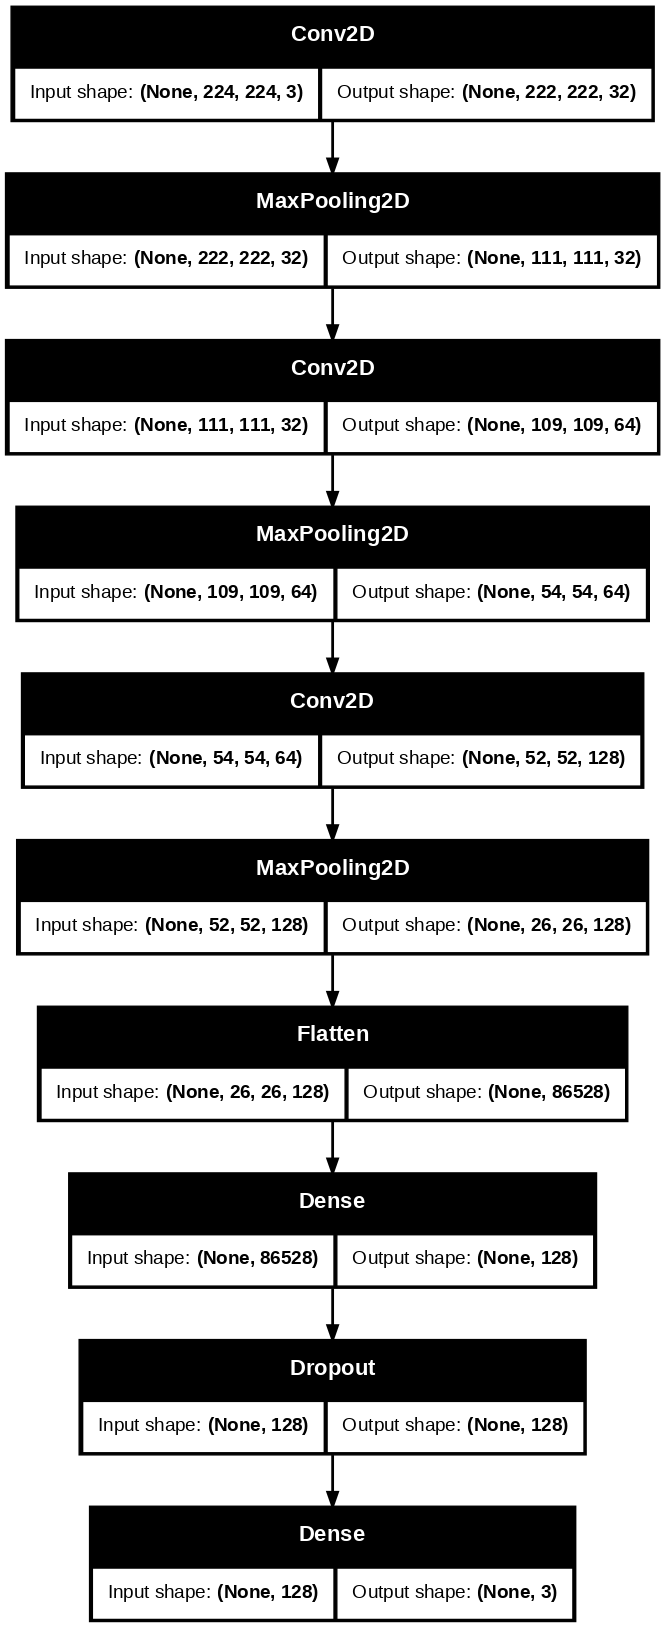

In [ ]:
dot_img_file = '/model_cnn.png'
keras.utils.plot_model(model, to_file=dot_img_file, show_shapes=True, dpi=100)

In [ ]:
def classify_image(image_path, model):
    img = tf.keras.preprocessing.image.load_img(image_path, target_size=image_size)
    img_array = tf.keras.preprocessing.image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Scale the image

    prediction = model.predict(img_array)
    class_labels = ['Minor', 'Moderate', 'Severe']
    return class_labels[np.argmax(prediction)]

# Test classification
# test_image = 'path_to_test_image'
# classification = classify_image(test_image, model)
# print(f"Damage Severity: {classification}")
